In [1]:
import pandas as pd
import kagglehub
import geopandas as gpd
import datetime as dt

# Download latest version
path = kagglehub.dataset_download("alexgude/california-traffic-collision-data-from-switrs")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/alexgude/california-traffic-collision-data-from-switrs/versions/6


## Data Cleaning

### Grab data for synethic control

In [2]:
import sqlite3
import os

path_to_dataset_dir = '/root/.cache/kagglehub/datasets/alexgude/california-traffic-collision-data-from-switrs/versions/6'
db_file_path = os.path.join(path_to_dataset_dir, 'switrs.sqlite')
conn = sqlite3.connect(db_file_path)

collisions = pd.read_sql_query("""
    SELECT case_id, collision_date, collision_severity, county_location, population, weather_1, primary_collision_factor, pcf_violation_category, hit_and_run, type_of_collision, road_condition_1, road_surface, lighting, alcohol_involved, latitude, longitude
    FROM collisions
    WHERE collision_date >= '2010-01-01' AND collision_date <= '2016-12-31';
""", conn)

collisions.head()

,case_id,collision_date,collision_severity,county_location,population,weather_1,primary_collision_factor,pcf_violation_category,hit_and_run,type_of_collision,road_condition_1,road_surface,lighting,alcohol_involved,latitude,longitude
0,4391974,2010-01-06,property damage only,los angeles,>250000,clear,other than driver,other than driver (or pedestrian),not hit and run,hit object,normal,dry,daylight,NaN,NaN,NaN
1,4392005,2010-01-19,fatal,riverside,unincorporated,cloudy,vehicle code violation,improper turning,not hit and run,hit object,normal,dry,dark with street lights,1.0,34.01847,-117.50958
2,4392006,2010-01-13,fatal,los angeles,50000 to 100000,raining,vehicle code violation,traffic signals and signs,not hit and run,broadside,normal,wet,dark with street lights,NaN,NaN,NaN
3,4392007,2010-01-15,fatal,los angeles,>250000,clear,vehicle code violation,pedestrian violation,felony,pedestrian,normal,dry,dark with street lights,1.0,NaN,NaN
4,4392008,2010-01-03,fatal,los angeles,>250000,cloudy,vehicle code violation,traffic signals and signs,not hit and run,broadside,normal,dry,daylight,NaN,NaN,NaN


In [3]:
print(collisions.shape)
print(collisions.columns)

(2929213, 16)
Index(['case_id', 'collision_date', 'collision_severity', 'county_location',
       'population', 'weather_1', 'primary_collision_factor',
       'pcf_violation_category', 'hit_and_run', 'type_of_collision',
       'road_condition_1', 'road_surface', 'lighting', 'alcohol_involved',
       'latitude', 'longitude'],
      dtype='object')


In [4]:
#drop lat lon
collisions = collisions.dropna(subset=['latitude', 'longitude'])

### Organize crashes to cities

In [5]:
import shapely

# Convert collisions DataFrame to a GeoDataFrame
geometry = gpd.points_from_xy(collisions['longitude'], collisions['latitude'])
collisions_gdf = gpd.GeoDataFrame(collisions, geometry=geometry, crs='EPSG:4326')

In [6]:
city_boundaries = gpd.read_file("/content/California_Cities_and_Identifiers_Blue_Version_view_9179458143702591125.geojson")
city_boundaries = city_boundaries[city_boundaries['OFFSHORE'].isna()]
city_boundaries = city_boundaries.to_crs(collisions_gdf.crs)

In [7]:
print(collisions_gdf.crs)
print(city_boundaries.crs)

EPSG:4326
EPSG:4326


In [8]:
city_boundaries['geometry'] = city_boundaries.buffer(0)
city_boundaries['geometry'].is_valid.value_counts()

,count
True,483


In [9]:
# Ensure city_boundaries also has a defined CRS
city_boundaries = city_boundaries.set_crs('EPSG:4326', allow_override=True)

collisions_clean = gpd.sjoin(
    collisions_gdf,
    city_boundaries,
    how='left',
    predicate='within'
)

Filter out the cities that implemented vision zero before 2017

In [10]:
filter_cities = ['Los Angeles', 'San Jose', 'San Diego', 'Fremont']

collisions_clean = collisions_clean[~collisions_clean['CDTFA_CITY'].isin(filter_cities)]
print(collisions_clean.shape)

(1092616, 35)


<Axes: >

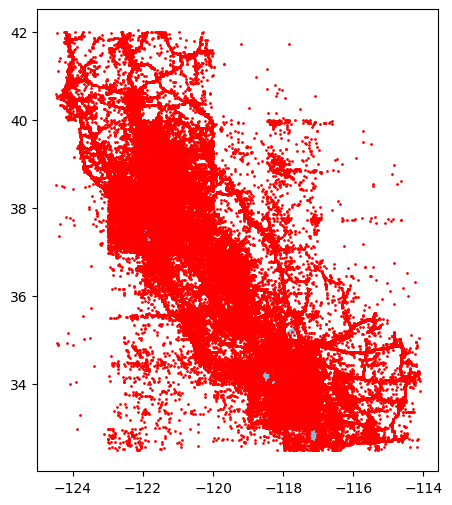

In [11]:
#plot collision cities
ax = city_boundaries.plot(figsize=(6,6), alpha=0.5)
collisions_clean.plot(ax=ax, color='red', markersize=1)

Get rid of crashes that happened outside of california

In [12]:
#get rid of crashes not in califronia
ca_boundary = gpd.read_file("State_Boundary_-2054994179663043177.geojson")
ca_boundary = ca_boundary.to_crs(collisions_clean.crs)

geometry = gpd.points_from_xy(collisions_clean['longitude'], collisions_clean['latitude'])
# collisions_clean is already a GeoDataFrame, no need to recreate it.
# Removing the line below ensures that all columns, including 'CDTFA_CITY', are preserved.
# collisions_clean = gpd.GeoDataFrame(collisions_clean, geometry=geometry, crs="EPSG:4326")

In [13]:
# Drop the 'index_right' column if it exists from the previous sjoin operation
if 'index_right' in collisions_clean.columns:
    collisions_clean = collisions_clean.drop(columns=['index_right'])

collisions_ca = gpd.sjoin(
    collisions_clean,
    ca_boundary,
    predicate="within",
    how="inner"
)

<Axes: >

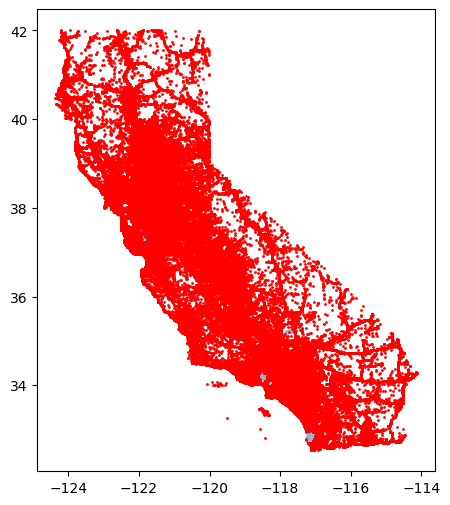

In [14]:
#plot collision cities
ax = city_boundaries.plot(figsize=(6,6), alpha=0.5)
collisions_ca.plot(ax=ax, color='red', markersize=1)

In [15]:
collisions_ca.shape

(1068378, 37)

### Label treatment by city and time


In [16]:
collisions_ca.columns

Index(['case_id', 'collision_date', 'collision_severity', 'county_location',
       'population', 'weather_1', 'primary_collision_factor',
       'pcf_violation_category', 'hit_and_run', 'type_of_collision',
       'road_condition_1', 'road_surface', 'lighting', 'alcohol_involved',
       'latitude', 'longitude', 'geometry', 'OBJECTID_left', 'CDTFA_COPRI',
       'CDTFA_CITY', 'CDTFA_COUNTY', 'CENSUS_PLACE_NAME', 'CENSUS_GEOID',
       'CENSUS_PLACE_TYPE', 'GNIS_PLACE_NAME', 'GNIS_ID', 'CDT_CITY_ABBR',
       'CDT_COUNTY_ABBR', 'PRIMARY_DOMAIN', 'CENSUS_POPULATION',
       'CDT_NAME_SHORT', 'OFFSHORE', 'AREA_SQMI', 'GlobalID', 'index_right',
       'OBJECTID_right', 'State'],
      dtype='object')

In [17]:
collisions_ca['collision_date'] = pd.to_datetime(collisions_ca['collision_date'])
collisions_ca['year_month'] = collisions_ca['collision_date'].dt.to_period('M')

In [18]:
print(collisions_ca.shape)
print(collisions_ca.columns)

(1068378, 38)
Index(['case_id', 'collision_date', 'collision_severity', 'county_location',
       'population', 'weather_1', 'primary_collision_factor',
       'pcf_violation_category', 'hit_and_run', 'type_of_collision',
       'road_condition_1', 'road_surface', 'lighting', 'alcohol_involved',
       'latitude', 'longitude', 'geometry', 'OBJECTID_left', 'CDTFA_COPRI',
       'CDTFA_CITY', 'CDTFA_COUNTY', 'CENSUS_PLACE_NAME', 'CENSUS_GEOID',
       'CENSUS_PLACE_TYPE', 'GNIS_PLACE_NAME', 'GNIS_ID', 'CDT_CITY_ABBR',
       'CDT_COUNTY_ABBR', 'PRIMARY_DOMAIN', 'CENSUS_POPULATION',
       'CDT_NAME_SHORT', 'OFFSHORE', 'AREA_SQMI', 'GlobalID', 'index_right',
       'OBJECTID_right', 'State', 'year_month'],
      dtype='object')


In [37]:
collisions_ca.to_csv('California_Collisions_Clean.csv')